In [1]:
import os
import sys
import matplotlib.pyplot as plt
from ViT_model import *

project_dir = os.path.abspath("../")
data_dir = os.path.join(project_dir, "data")

In [9]:
# Define transform for the dataset
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Load the dataset
from NIH_dataset import *
dataset_train = NIH_Dataset(data_dir, data_type="train", transform=transform)
dataloader_train = DataLoader(dataset_train, batch_size=1, shuffle=False)

# dataset_test = NIH_Dataset(data_dir, data_type="test", transform=transform)
# dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

Number of training images: 100


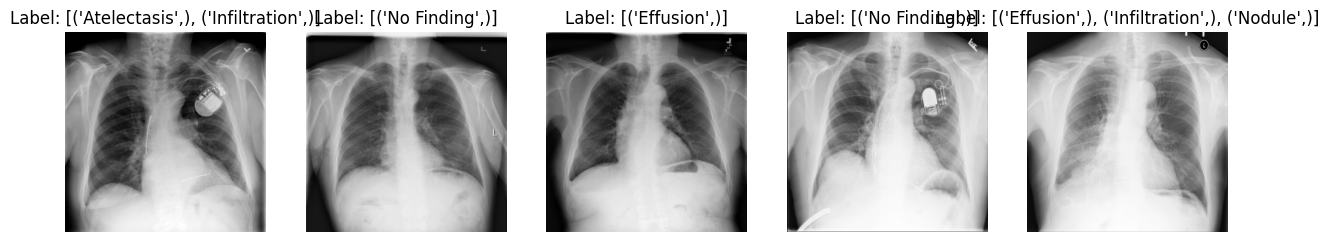

In [3]:
# Display 5 training images with labels
def show_images(dataloader, num_images=5):
    plt.figure(figsize=(15, 5))
    for i, (image, label, encoded_labels) in enumerate(dataloader):
        if i >= num_images:
            break
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image[0].permute(1, 2, 0).numpy(), cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.show()
# Show training images
show_images(dataloader_train, num_images=5)

### Test pretrained model

In [10]:
vit_model = 'vit_b_16'
num_classes = dataset_train.num_classes

device = torch.device("cuda" if torch.cuda.is_available() 
                else "mps" if torch.backends.mps.is_available()
                else "cpu")
print(f"Using device: {device}")

model = ViTModel(vit_model, num_classes=num_classes, pretrained=True)
model.to(device)

# Run inferrence on first 5 test images
def run_inference(dataloader, model, num_images=5):
    model.eval()
    with torch.no_grad():
        for i, (image, label, encoded_labels) in enumerate(dataloader):
            if i >= num_images:
                break
            image = image.unsqueeze(1) if image.ndim == 3 else image
            image = image.to(device)
            print(f"Image {i+1}: {image.shape}")
            outputs = model(image)
            print(f"Image {i+1}: {outputs}")
            _, predicted = torch.max(outputs, 1)
            print(f"Image {i+1}: True label: {label}, Predicted label: {predicted.item()}")

run_inference(dataset_train, model, num_images=5)

Using device: mps
Image 1: torch.Size([1, 1, 224, 224])
Image 1: tensor([[0.2645, 0.6446, 0.6579, 0.5705, 0.6354, 0.4470, 0.4182, 0.5339, 0.4503,
         0.6221, 0.8848, 0.9023, 0.9053, 0.8881, 0.8436, 0.8512, 0.9351, 0.7415,
         0.9229, 0.8281, 0.6744, 0.9923, 0.9799, 0.9691, 0.7108, 0.3058, 0.4925,
         0.4523, 0.4117, 0.3801, 0.3651, 0.6875, 0.3708, 0.4052, 0.4709, 0.3410,
         0.4469, 0.2313, 0.5387, 0.4403, 0.8003, 0.4297, 0.6352, 0.4098, 0.4185,
         0.3361, 0.7375, 0.4319, 0.3428, 0.4066, 0.4884, 0.2163, 0.5746, 0.5617,
         0.3792, 0.6197, 0.3784, 0.3768, 0.4479, 0.7534, 0.3767, 0.3345, 0.3638,
         0.6481, 0.7211, 0.5133, 0.3996, 0.3248, 0.3538, 0.4355, 0.6253, 0.7131,
         0.6011, 0.8545, 0.6583, 0.8304, 0.4394, 0.7579, 0.9405, 0.7505, 0.7423,
         0.8177, 0.7312, 0.4703, 0.5929, 0.8225, 0.6943, 0.5190, 0.5992, 0.8873,
         0.5593, 0.8228, 0.9700, 0.8026, 0.9325, 0.6219, 0.7610, 0.5928, 0.7374,
         0.7677, 0.6149, 0.2039, 0.2151, 0.6